
# Exercises XP - Diabetes Classification

## What you will learn
- Understanding the problem
- Data collection
- Model training for classification
- Model evaluation

## What you will create
- A Logistic Regression model to predict diabetes



## Exercise 1 - Understanding the problem and Data Collection

We want to predict if an individual has diabetes.

- Load the diabetes dataset and explore it
- Count positive and negative cases
- Split the data into train and test


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:

# TODO: load the dataset
# If running on Colab, upload the zip or csv then adjust the path

df = pd.read_csv('diabetes_prediction_dataset.csv')

print(df.shape)
display(df.head())
print(df.dtypes)
print("Missing per column:")
display(df.isna().sum().sort_values(ascending=False))


(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object
Missing per column:


,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [5]:
# Assume target column is named 'diabetes' with 0 or 1 values
assert 'diabetes' in df.columns, "Expected a 'diabetes' target column"
print(df['diabetes'].value_counts())


diabetes
0    91500
1     8500
Name: count, dtype: int64


In [6]:

# TODO: train test split
from sklearn.model_selection import train_test_split
X = df.drop(columns=['diabetes'])
y = df['diabetes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape)


(80000, 8) (20000, 8)



## Exercise 2 - Model picking and standardization

- Which model can we use and why
- Do we need to standardize
- If yes, apply StandardScaler



> For the binary classification task, Logistic Regression is a strong choice because it models a linear decision boundary between the two classes, provides calibrated probabilities that are useful for threshold tuning and risk assessment, and offers interpretability through its coefficients, which indicate the influence of each feature on the likelihood of diabetes.

> Logistic Regression relies on numerical optimization, standardization of features using StandardScaler is important: it improves numerical stability, ensures features are on comparable scales, and leads to better-conditioned optimization problems, ultimately making training more efficient and reliable.


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify categorical and numeric columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

# Build preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('numeric', StandardScaler(), num_cols)
    ]
)

print("Categorical:", cat_cols)
print("Numeric:", num_cols)



Categorical: ['gender', 'smoking_history']
Numeric: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']


## Exercise 3 - Model training

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Build pipeline: preprocessing + classifier
clf = Pipeline([
    ('preprocess', preprocess),   # your ColumnTransformer
    ('classifier', LogisticRegression(max_iter=1000))  # model
])

# Train the pipeline
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)



## Exercise 4 - Evaluation metrics

- Plot accuracy and comment
- Plot confusion matrix and comment
- Plot precision, recall, F1 and comment


Accuracy: 0.9605
Precision: 0.8587
Recall: 0.64
F1: 0.7334


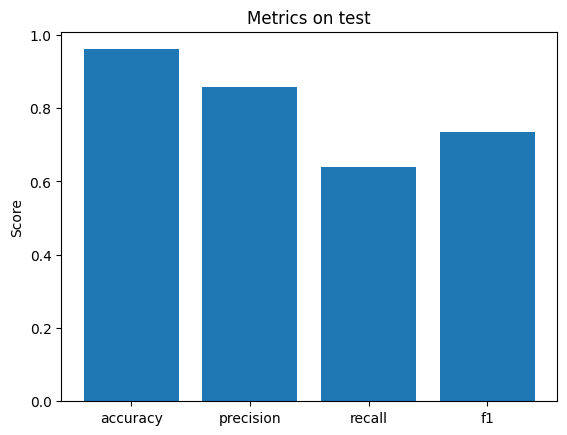

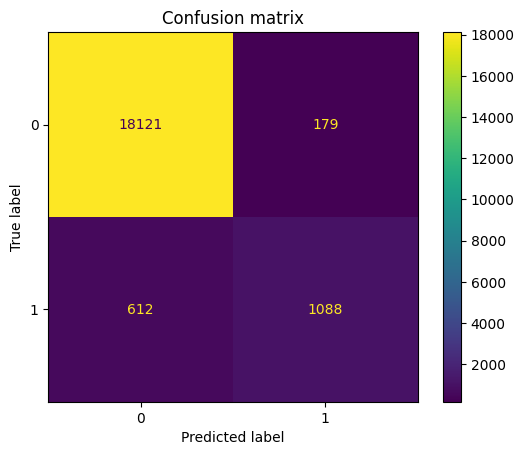

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred = clf.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='binary')   # or 'macro'/'weighted' if multiclass
rec = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

print("Accuracy:", round(acc,4))
print("Precision:", round(prec,4))
print("Recall:", round(rec,4))
print("F1:", round(f1,4))

# Simple bar plot of metrics
import matplotlib.pyplot as plt
plt.figure()
plt.bar(['accuracy','precision','recall','f1'], [acc,prec,rec,f1])
plt.title('Metrics on test')
plt.ylabel('Score')
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion matrix')
plt.show()


The model achieves high precision, meaning its positive predictions are usually correct. However, recall is lower, so it misses a portion of actual positives. This suggests the model is cautious in predicting positives, prioritizing correctness over completeness.


## Exercise 5 - Visualizing the performance of our model

Visualize a 2D decision boundary with accuracy info. Use only two informative features for this plot to keep it 2D. Suggested pair: `HbA1c_level` and `blood_glucose_level` if present. Otherwise pick any two numeric features.


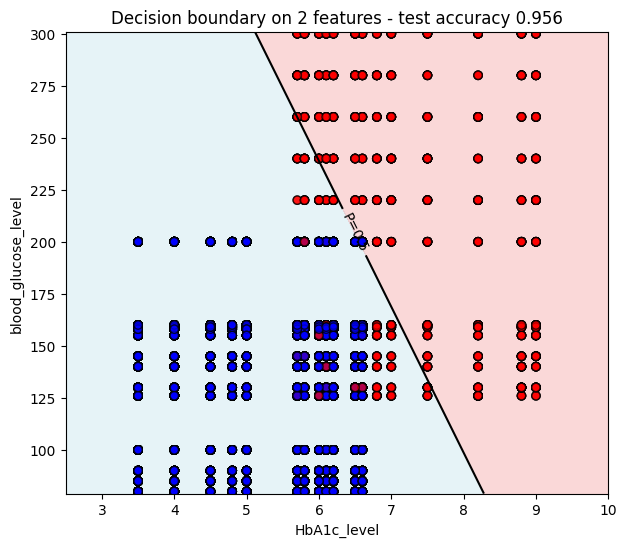

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Pick two numeric features
feat_x = 'HbA1c_level' if 'HbA1c_level' in X.columns else X.select_dtypes(include=['int64','float64']).columns[0]
feat_y = 'blood_glucose_level' if 'blood_glucose_level' in X.columns else X.select_dtypes(include=['int64','float64']).columns[1]

X2_train = X_train[[feat_x, feat_y]].copy()
X2_test = X_test[[feat_x, feat_y]].copy()

# Pipeline: scale + logistic regression
pipe2 = Pipeline([
    ('pre', ColumnTransformer([('num', StandardScaler(), [0,1])], remainder='drop')),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
pipe2.fit(X2_train.values, y_train)

# Mesh grid for decision boundary
x_min, x_max = X2_train[feat_x].min()-1, X2_train[feat_x].max()+1
y_min, y_max = X2_train[feat_y].min()-1, X2_train[feat_y].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

probs = pipe2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)

# Plot shaded decision regions
plt.figure(figsize=(7,6))
plt.contourf(xx, yy, probs, levels=[0,0.5,1], alpha=0.3, colors=['lightblue','lightcoral'])
cs = plt.contour(xx, yy, probs, levels=[0.5], colors='k')
plt.clabel(cs, inline=True, fmt=lambda x: 'P=0.5')

# Scatter test points
plt.scatter(X2_test[feat_x], X2_test[feat_y], c=y_test, cmap='bwr', edgecolor='k', alpha=0.7)

# Accuracy
acc2 = accuracy_score(y_test, pipe2.predict(X2_test.values))
plt.title(f'Decision boundary on 2 features - test accuracy {acc2:.3f}')
plt.xlabel(feat_x)
plt.ylabel(feat_y)
plt.show()







## Exercise 6 - ROC curve

Use the code template provided to plot the ROC curve for your model and compute AUC. You can reuse the fitted `clf` pipeline.

Template summary:
- Get predicted probabilities for the positive class
- Compute fpr and tpr with `roc_curve`
- Plot ROC and print AUC


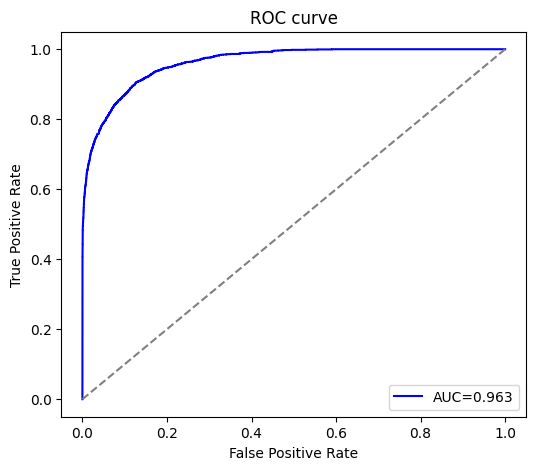

ROC AUC: 0.963


In [12]:

from sklearn import metrics

# Get predicted probabilities for the positive class
y_proba = clf.predict_proba(X_test)[:, 1]

# Compute ROC curve values
fpr, tpr, _ = metrics.roc_curve(y_test, y_proba)

# Compute AUC
auc = metrics.roc_auc_score(y_test, y_proba)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC={auc:.3f}', color='blue')
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.legend(loc=4)
plt.show()

print(f"ROC AUC: {auc:.3f}")



> TODO: interpret the ROC curve and AUC from results of execution of cell above.

The ROC curve shows a strong separation between classes, with the curve rising sharply toward the top-left corner. The AUC score of 0.87 indicates that the model has a high ability to distinguish between positive and negative cases. This suggests reliable classification performance across different thresholds.